#   Whisper ASR Benchmark on TED-LIUM Test Set (Tiny / Base / Small)

Notebook này được thiết kế để chạy thực nghiệm đánh giá và so sánh chi tiết giữa hai framework phổ biến là **HuggingFace Transformers** và **Faster-Whisper (CTranslate2)** đối với 3 kích thước mô hình: **Tiny, Base, và Small**.

### Các chỉ số đo lường:
1. **Word Error Rate (WER %)**: Độ chính xác nhận dạng từ lỗi.
2. **Real-Time Factor (RTF)**: Tốc độ xử lý (thời gian nhận dạng / thời lượng audio). Chỉ số càng nhỏ chạy càng nhanh.
3. **Peak GPU Memory (VRAM MB)**: Bộ nhớ đồ họa tối đa tiêu thụ (chỉ quét được các tensor PyTorch).
4. **Model Load Time (giây)**: Thời gian tải mô hình vào bộ nhớ.

---

## 1. Cài đặt các thư viện cần thiết
Hãy bỏ chú thích dòng lệnh dưới đây để cài đặt các thư viện nếu môi trường của bạn chưa có sẵn.

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install faster-whisper transformers datasets jiwer soundfile pandas matplotlib tabulate

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Thiết lập Môi trường và Import thư viện

In [2]:
import os
import json
import time
import re
import gc
import io
import soundfile as sf
import torch
import jiwer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datasets
from datasets import load_dataset

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.12.0+cu126
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


## 3. Tải tập dữ liệu TED-LIUM Test Split
Chúng ta sẽ stream dữ liệu test từ HuggingFace và tắt cơ chế tự động decode audio mặc định (để tránh các lỗi liên quan đến thư viện `torchcodec` trên môi trường Windows).

In [3]:
NUM_SAMPLES = 100
dataset_name = "distil-whisper/tedlium"
config_name = "default"

print(f"Loading {dataset_name} test split in streaming mode (decode=False)...")
dataset = load_dataset(
    dataset_name,
    config_name,
    revision="refs/convert/parquet",
    streaming=True
)

# Cast column to disable auto-decoding
dataset = dataset.cast_column("audio", datasets.Audio(decode=False))

# Thu thập NUM_SAMPLES mẫu test hợp lệ
test_iter = iter(dataset["test"])
samples = []
while len(samples) < NUM_SAMPLES:
    try:
        sample = next(test_iter)
        ref_text = sample.get("text", "")
        if ref_text == "ignore_time_segment_in_scoring" or not ref_text.strip():
            continue
        samples.append(sample)
    except StopIteration:
        break
        
print(f"Collected {len(samples)} valid test samples for benchmarking.")

# Tính toán tổng thời lượng audio thực tế
total_audio_duration = 0
for s in samples:
    audio_bytes = s["audio"]["bytes"]
    info = sf.info(io.BytesIO(audio_bytes))
    total_audio_duration += info.duration
    
print(f"Total Audio Duration: {total_audio_duration:.2f} seconds ({total_audio_duration/60:.2f} minutes)")

Loading distil-whisper/tedlium test split in streaming mode (decode=False)...


Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Collected 100 valid test samples for benchmarking.
Total Audio Duration: 947.90 seconds (15.80 minutes)


## 4. Định nghĩa hàm Helper chuẩn hóa & Benchmark

In [4]:
def normalize_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Loại bỏ dấu câu
    text = re.sub(r'\s+', ' ', text)     # Thu gọn khoảng trắng
    return text.strip()

def run_transformers_pipeline(asr_pipeline, vad_model, get_speech_timestamps, audio_arr, sr=16000):
    chunk_sec = 30
    chunk_samples = chunk_sec * sr
    full_text_list = []
    
    for i in range(0, len(audio_arr), chunk_samples):
        chunk = audio_arr[i:i+chunk_samples]
        if len(chunk) < 0.5 * sr:
            continue
            
        t_start = i / sr
        t_end = min(len(audio_arr), i + chunk_samples) / sr
        
        is_silent = False
        if vad_model is not None and get_speech_timestamps is not None:
            try:
                chunk_tensor = torch.from_numpy(chunk).float()
                speech_ts = get_speech_timestamps(chunk_tensor, vad_model, sampling_rate=16000)
                if not speech_ts:
                    is_silent = True
            except Exception as vad_err:
                pass
        
        if is_silent:
            continue
            
        try:
            res = asr_pipeline(
                {"array": chunk, "sampling_rate": sr},
                return_timestamps="word",
                generate_kwargs={"task": "transcribe", "language": "english"}
            )
            chunk_text = res.get("text", "").strip()
            if chunk_text and chunk_text != "[Nhạc nền / Im lặng]":
                full_text_list.append(chunk_text)
        except Exception:
            pass
            
    return " ".join(full_text_list)

def run_faster_whisper_pipeline(fw_model, audio_arr, sr=16000):
    segments_gen, info = fw_model.transcribe(
        audio_arr,
        beam_size=5,
        vad_filter=True,
        vad_parameters=dict(min_silence_duration_ms=2000),
        word_timestamps=True
    )
    
    full_text_list = []
    for segment in segments_gen:
        segment_text = segment.text.strip()
        if not segment_text:
            continue
        full_text_list.append(segment_text)
        
    return " ".join(full_text_list)

def run_model_benchmark(model_cfg, samples, total_duration):
    model_name = model_cfg["name"]
    model_type = model_cfg["type"]
    model_id = model_cfg["model_id"]
    
    print(f"\nEvaluating {model_name}...")
    
    # Kiểm tra GPU
    gpu_ok = False
    if torch.cuda.is_available():
        major, minor = torch.cuda.get_device_capability(0)
        if major >= 7:
            gpu_ok = True
            
    # Dọn dẹp GPU memory
    if gpu_ok:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        gc.collect()
    
    t_start_load = time.time()
    device_to_use = "cuda" if gpu_ok else "cpu"
    
    # Load mô hình
    vad_model = None
    get_speech_timestamps = None
    
    if model_type == "transformers":
        from transformers import pipeline
        success = False
        if device_to_use == "cuda":
            try:
                # Thử load GPU với float16
                asr_pipeline = pipeline(
                    "automatic-speech-recognition",
                    model=model_id,
                    device=0,
                    torch_dtype=torch.float16
                )
                dummy_input = {"array": np.zeros(16000, dtype=np.float32), "sampling_rate": 16000}
                asr_pipeline(dummy_input)
                success = True
                print("Loaded successfully on GPU (float16)")
            except Exception as e:
                print(f"Transformers GPU float16 failed ({e}), trying float32...")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                gc.collect()
                try: 
                    asr_pipeline = pipeline(
                        "automatic-speech-recognition",
                        model=model_id,
                        device=0,
                        torch_dtype=torch.float32
                    )
                    dummy_input = {"array": np.zeros(16000, dtype=np.float32), "sampling_rate": 16000}
                    asr_pipeline(dummy_input)
                    success = True
                    print("Loaded successfully on GPU (float32)")
                except Exception as e2:
                    print(f"Transformers GPU float32 failed ({e2}), falling back to CPU...")
        
        if not success:
            asr_pipeline = pipeline(
                "automatic-speech-recognition",
                model=model_id,
                device=-1,
                torch_dtype=torch.float32
            )
            print("Loaded successfully on CPU (float32)")
            device_to_use = "cpu"
            
        # Thử load Silero VAD cho HuggingFace Transformers pipeline
        try:
            print("Loading Silero VAD for voice activity check...")
            torch.hub.set_dir(os.path.join(os.getcwd(), "cache", "torch_hub"))
            vad_model, vad_utils = torch.hub.load(
                repo_or_dir='snakers4/silero-vad',
                model='silero_vad',
                trust_repo=True,
                force_reload=False
            )
            get_speech_timestamps = vad_utils[0]
            print("Silero VAD loaded successfully.")
        except Exception as vad_err:
            print(f"[Warning] Silero VAD initialization failed: {vad_err}. Processing raw chunks directly.")
    else:
        from faster_whisper import WhisperModel
        success = False
        
        if device_to_use == "cuda":
            for comp_type in ["float16", "int8_float16", "float32"]:
                try:
                    print(f"Attempting to load {model_name} on GPU with compute_type={comp_type}...")
                    fw_model = WhisperModel(model_id, device="cuda", compute_type=comp_type)
                    dummy_input = np.zeros(16000, dtype=np.float32)
                    list(fw_model.transcribe(dummy_input, beam_size=1))
                    success = True
                    print(f"Loaded successfully on GPU with compute_type={comp_type}")
                    break
                except Exception as e:
                    print(f"compute_type={comp_type} initialization failed: {e}")
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                    gc.collect()
                    
        if not success:
            print("Faster-Whisper GPU execution failed or unavailable. Falling back to CPU (compute_type=int8)...")
            fw_model = WhisperModel(model_id, device="cpu", compute_type="int8")
            device_to_use = "cpu"
        
    load_time = time.time() - t_start_load
    print(f"Loaded in {load_time:.2f} seconds")

    # Tiến hành nhận dạng thử nghiệm
    transcribe_times = []
    hypotheses = []
    references = []
    
    for idx, sample in enumerate(samples):
        audio_bytes = sample["audio"]["bytes"]
        audio_data, sampling_rate = sf.read(io.BytesIO(audio_bytes))
        if len(audio_data.shape) > 1:
            audio_data = audio_data.mean(axis=1)
        audio_arr = audio_data.astype(np.float32)
        ref_text = sample["text"]
        
        t_trans_start = time.time()
        if model_type == "transformers":
            pred_text = run_transformers_pipeline(asr_pipeline, vad_model, get_speech_timestamps, audio_arr, sampling_rate)
        else:
            pred_text = run_faster_whisper_pipeline(fw_model, audio_arr, sampling_rate)
            
        transcribe_times.append(time.time() - t_trans_start)
        references.append(normalize_text(ref_text))
        hypotheses.append(normalize_text(pred_text))
        
    total_transcribe_time = sum(transcribe_times)
    rtf = total_transcribe_time / total_duration
    wer = jiwer.wer(references, hypotheses)
    
    if torch.cuda.is_available() and device_to_use == "cuda":
        peak_vram = torch.cuda.max_memory_allocated(0) / (1024 * 1024)
    else:
        peak_vram = 0
        
    # Dọn dẹp RAM/VRAM
    if model_type == "transformers":
        del asr_pipeline
        if vad_model is not None:
            del vad_model
        if get_speech_timestamps is not None:
            del get_speech_timestamps
    else:
        del fw_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    print(f"==> Result: RTF = {rtf:.4f} | WER = {wer*100:.2f}% | Peak VRAM = {peak_vram:.1f} MB")
    
    return {
        "Model": model_name,
        "Type": model_type,
        "RTF": rtf,
        "WER (%)": wer * 100,
        "Peak VRAM (MB)": peak_vram,
        "Load Time (s)": load_time
    }

## 5. Chạy Tiến trình Đánh giá (Benchmark Execution)

In [5]:
models_to_test = [
    {"name": "whisper-tiny (HF)", "type": "transformers", "model_id": "openai/whisper-tiny"},
    {"name": "tiny.en (FW)", "type": "faster-whisper", "model_id": "tiny.en"},
    {"name": "whisper-base (HF)", "type": "transformers", "model_id": "openai/whisper-base"},
    {"name": "base.en (FW)", "type": "faster-whisper", "model_id": "base.en"},
    {"name": "whisper-small (HF)", "type": "transformers", "model_id": "openai/whisper-small"},
    {"name": "small.en (FW)", "type": "faster-whisper", "model_id": "small.en"},
    {"name": "whisper-medium (HF)", "type": "transformers", "model_id": "openai/whisper-medium"},
    {"name": "medium.en (FW)", "type": "faster-whisper", "model_id": "medium.en"},
    {"name": "whisper-large-v3 (HF)", "type": "transformers", "model_id": "openai/whisper-large-v3"},
    {"name": "large-v3 (FW)", "type": "faster-whisper", "model_id": "large-v3"}
]

results = []
for m_cfg in models_to_test:
    try:
        metrics = run_model_benchmark(m_cfg, samples, total_audio_duration)
        results.append(metrics)
    except Exception as e:
        print(f"Thực nghiệm lỗi với {m_cfg['name']}: {e}")
        import traceback
        traceback.print_exc()


Evaluating whisper-tiny (HF)...


`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Device set to use cuda:0
`return_token_timestamps` is deprecated for WhisperFeatureExtractor and will be removed in Transformers v5. Use `return_attention_mask` instead, as the number of frames can be inferred from it.
Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


Loaded successfully on GPU (float16)
Loading Silero VAD for voice activity check...


...

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

Device set to use cuda:0


Loaded successfully on GPU (float16)
Loading Silero VAD for voice activity check...


Using cache found in c:\Users\hung\Documents\GitHub\multimodal-lecture-summarizer\multimodal-lecture-summarizer\experiments\notebooks\cache\torch_hub\snakers4_silero-vad_master


Silero VAD loaded successfully.
Loaded in 43.97 seconds
==> Result: RTF = 2.6478 | WER = 10.10% | Peak VRAM = 9606.7 MB

Evaluating large-v3 (FW)...
Attempting to load large-v3 (FW) on GPU with compute_type=float16...
Loaded successfully on GPU with compute_type=float16
Loaded in 7.96 seconds
==> Result: RTF = 0.1474 | WER = 9.76% | Peak VRAM = 8.1 MB


## 6. Trực quan hóa Kết quả và Phân tích

,Model,Type,RTF,WER (%),Peak VRAM (MB),Load Time (s)
0,whisper-tiny (HF),transformers,0.204954,11.975435,502.567383,77.383698
1,tiny.en (FW),faster-whisper,0.034560,11.122484,8.125000,1.660326
2,whisper-base (HF),transformers,0.286293,11.122484,834.779297,11.810760
3,base.en (FW),faster-whisper,0.053537,10.508359,8.125000,0.996717
4,whisper-small (HF),transformers,0.406536,18.150802,2574.968750,5.895822
5,small.en (FW),faster-whisper,0.090165,9.928352,8.125000,1.989896
6,whisper-medium (HF),transformers,0.849061,18.082566,7269.402832,51.763261
7,medium.en (FW),faster-whisper,0.099217,10.167178,8.125000,4.627863
8,whisper-large-v3 (HF),transformers,2.647832,10.098942,9606.714844,43.972317
9,large-v3 (FW),faster-whisper,0.147384,9.757762,8.125000,7.959243


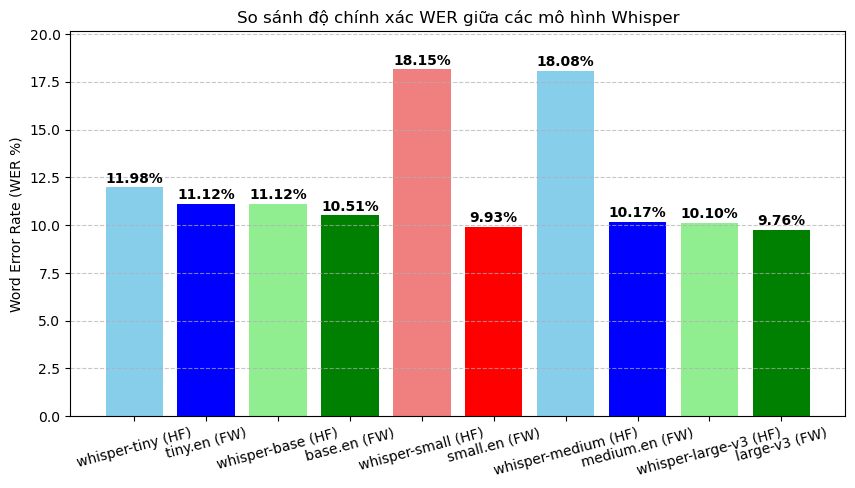

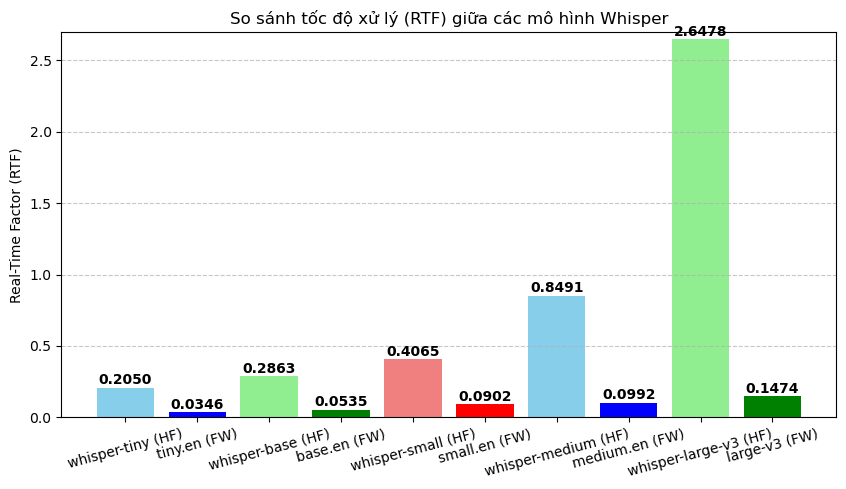

In [6]:
if results:
    df = pd.DataFrame(results)
    display(df)
    
    # Vẽ biểu đồ so sánh WER
    plt.figure(figsize=(10, 5))
    bars = plt.bar(df['Model'], df['WER (%)'], color=['skyblue', 'blue', 'lightgreen', 'green', 'lightcoral', 'red'])
    plt.ylabel('Word Error Rate (WER %)')
    plt.title('So sánh độ chính xác WER giữa các mô hình Whisper')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')
    plt.ylim(0, max(df['WER (%)']) + 2)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=15)
    plt.show()
    
    # Vẽ biểu đồ so sánh RTF
    plt.figure(figsize=(10, 5))
    bars = plt.bar(df['Model'], df['RTF'], color=['skyblue', 'blue', 'lightgreen', 'green', 'lightcoral', 'red'])
    plt.ylabel('Real-Time Factor (RTF)')
    plt.title('So sánh tốc độ xử lý (RTF) giữa các mô hình Whisper')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')
    plt.ylim(0, max(df['RTF']) + 0.05)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=15)
    plt.show()
else:
    print("Không có kết quả thực nghiệm để trực quan hóa.")

Kết luận : 
Độ chính xác (Accuracy): Mô hình small.en (FW) đạt độ chính xác tốt nhất với chỉ số WER là 9.93%
Tốc độ & Tài nguyên: Thư viện Faster-Whisper (FW) vượt trội hơn hẳn HuggingFace (HF) trên mọi kích thước mô hình (nhanh hơn từ 3.5 đến 4 lần và thời gian load mô hình gần như ngay lập tức).
Kết luận cho hệ thống: Bạn nên kiến nghị sử dụng small.en (hoặc medium nếu GPU mạnh hơn) chạy trên framework Faster-Whisper cho Audio Module của hệ thống.


Thực nghiệm đề xuất hệ thống sử dụng mô hình large-v3 trên framework Faster-Whisper (FW) làm mặc định cho Audio Module để đảm bảo độ chính xác nhận dạng cao nhất (WER 9.76%). Trong trường hợp tài nguyên phần cứng bị giới hạn (thiết bị không có GPU chuyên dụng hoặc VRAM dưới 4GB), mô hình small.en (FW) là giải pháp thay thế tối ưu nhất với WER 9.93% và tốc độ xử lý cực nhanh (RTF 0.09). Đồng thời, báo cáo khuyến nghị loại bỏ phương án sử dụng thư viện Transformers (HF) do hiệu năng kém và yêu cầu VRAM quá cao.
